Ergebnisse visualisieren

Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Plots

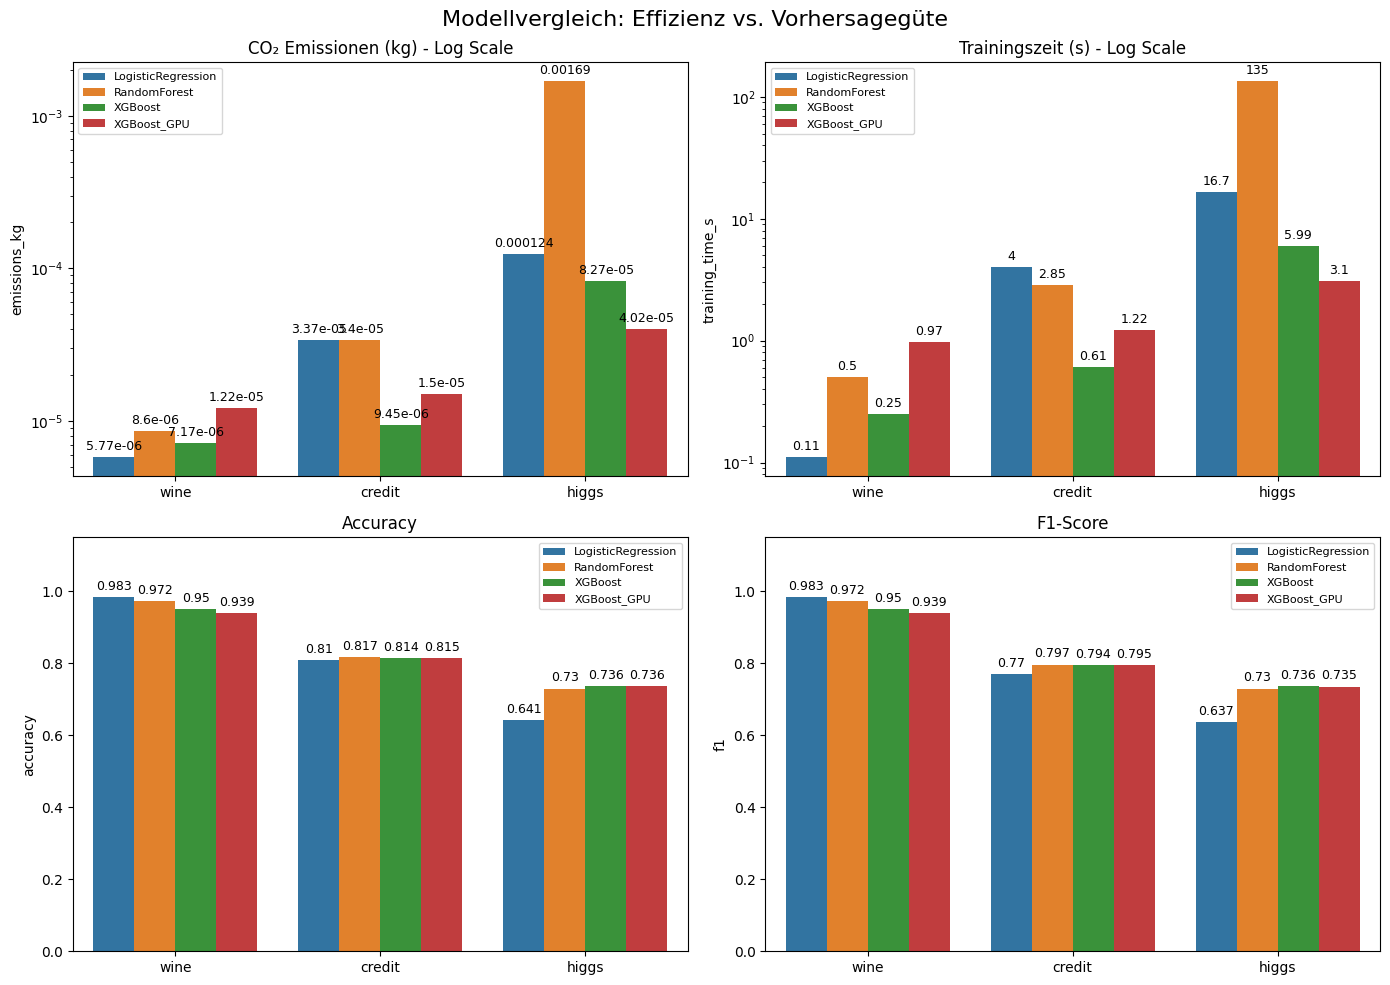

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten einlesen & bereinigen
df = pd.read_csv("../results/results.csv")

# Nur relevante Spalten behalten (score-Experimente ignorieren)
df = df[["timestamp", "model", "dataset", "nrows", "accuracy", "f1", "emissions_kg", "training_time_s"]]

# Neuesten Run pro Kombination behalten
df = df.drop_duplicates(subset=["dataset", "nrows", "model"], keep="last")

# Label nur wo nötig (higgs hat mehrere nrows, wine/credit nicht)
df["model_label"] = df.apply(
    lambda r: f"{r['model']} ({r['nrows']})"
    if df[df["dataset"] == r["dataset"]]["nrows"].nunique() > 1
    else r["model"],
    axis=1
)

# 2. Visualisierung aufbauen
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Modellvergleich: Effizienz vs. Vorhersagegüte", fontsize=16)

# Oben Links: Emissionen
sns.barplot(data=df, x="dataset", y="emissions_kg", hue="model_label", ax=axes[0, 0])
axes[0, 0].set_title("CO₂ Emissionen (kg) - Log Scale")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("")

# Oben Rechts: Trainingszeit
sns.barplot(data=df, x="dataset", y="training_time_s", hue="model_label", ax=axes[0, 1])
axes[0, 1].set_title("Trainingszeit (s) - Log Scale")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("")

# Unten Links: Accuracy
sns.barplot(data=df, x="dataset", y="accuracy", hue="model_label", ax=axes[1, 0])
axes[1, 0].set_title("Accuracy")
axes[1, 0].set_ylim(0, 1.15)
axes[1, 0].set_xlabel("")

# Unten Rechts: F1-Score
sns.barplot(data=df, x="dataset", y="f1", hue="model_label", ax=axes[1, 1])
axes[1, 1].set_title("F1-Score")
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].set_xlabel("")

# 3. Absolute Zahlen über Balken
for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3g", padding=3, fontsize=9)

# 4. Legenden anpassen
for ax in axes.flat:
    ax.legend(fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.savefig("../results/vergleich.png", dpi=150, bbox_inches="tight")
plt.show()